In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
#Cargo los archivos .pkl
df_contactos = pd.read_pickle('data/df_contactos_clean.pkl')
df_agentes = pd.read_pickle('data/df_agentes_clean.pkl')
df_calendario = pd.read_pickle('data/df_calendario_clean.pkl')
df_campañas = pd.read_pickle('data/df_campañas_clean.pkl')

## 1. Información general de los KPIs.

### Canal de contacto más utilizado.

In [5]:
uso_por_canal = df_contactos['canal'].value_counts(normalize=True).mul(100).round(2)
uso_por_canal

canal
Teléfono    59.92
Chat        25.01
Email       15.07
Name: proportion, dtype: float64

### Área con mayor volumen de contactos

In [6]:
area_mas_contactada = df_contactos['departamento'].value_counts(normalize=True).mul(100).round(2)
area_mas_contactada

departamento
ATC                58.85
Soporte Técnico    23.52
Ventas             17.63
Name: proportion, dtype: float64

### SLA y AHT por departamentos

In [7]:
#Calculo AHT por área, en segunddos
aht_area = df_contactos.groupby(['departamento'])['duracion_segundos'].mean().round(2)
aht_area

departamento
ATC                323.27
Soporte Técnico    525.87
Ventas             222.05
Name: duracion_segundos, dtype: float64

In [8]:
#Calculo AHT por área, en minutos
aht_area_minutos = (aht_area / 60).round(2)
aht_area_minutos

departamento
ATC                5.39
Soporte Técnico    8.76
Ventas             3.70
Name: duracion_segundos, dtype: float64

In [9]:
sla_area = (df_contactos.groupby('departamento')['SLA_cumplido'].mean() * 100).round(1)
sla_area

departamento
ATC                89.9
Soporte Técnico    89.8
Ventas             90.0
Name: SLA_cumplido, dtype: float64

### Tasa de resolución

In [10]:
tasa_resolucion = (df_contactos['resuelto'].mean() * 100).round(2)
print(round(float(tasa_resolucion), 1))

92.0


### Adherencia de planificación.

In [11]:
adherencia = (df_agentes['agentes_presentes'].sum()/df_agentes['agentes_programados'].sum()*100).round(1)
print(round(float(adherencia), 1))

94.8


### Tasa de absentismo.

In [12]:
tasa_absentismo = (df_agentes['ausencias'].sum()/df_agentes['agentes_programados'].sum()*100).round(1)
print(round(float(tasa_absentismo), 1))

5.2


### Tasa vacaciones

In [13]:
tasa_vacaciones =  (df_agentes['vacaciones'].sum()/df_agentes['agentes_programados'].sum()*100).round(1)
print(round(float(tasa_vacaciones), 1))

9.7


## Conclusiones — KPIs generales

**Canal de contacto más utilizado**
Teléfono concentra el 59.9% de los contactos, muy por delante de Chat (25.0%) y Email (15.1%). Es el canal claramente dominante, con implicaciones directas para el dimensionamiento de personal: la mayor parte de la capacidad operativa debe orientarse a atención telefónica.

**Área con mayor volumen de contactos**
ATC concentra el 58.9% de los contactos, muy por encima de Soporte Técnico (23.5%) y Ventas (17.6%). Esto confirma lo descrito en el contexto de negocio: *"ATC es el departamento con mayor volumen de contactos"*.

**AHT y SLA por departamento**
- El AHT sigue el patrón esperado: **Soporte Técnico (8.76 min) > ATC (5.39 min) > Ventas (3.70 min)**, coherente con la descripción del contexto (*"Soporte Técnico presenta una duración media significativamente superior"* y *"Ventas, menor tiempo medio de atención"*).
- El SLA, en cambio, es prácticamente homogéneo entre departamentos (**ATC 89.9%, Soporte Técnico 89.8%, Ventas 90.0%**), pese a tener AHT muy distintos. Esto sugiere que el dimensionamiento de agentes está ajustado de forma diferenciada por departamento (más agentes donde el AHT es mayor) para sostener un nivel de servicio similar en los tres. Los tres están justo en el entorno del **90% objetivo** marcado en el contexto del proyecto.

**Tasa de resolución**
92.0% de los contactos quedan resueltos globalmente, un dato saludable y consistente con una operación bien gestionada.

**Adherencia a la planificación**
94.8% de adherencia global: la plantilla presente se ajusta bien a la programada.

**Absentismo**
5.2%, dentro de un rango normal-bueno para el sector (por debajo del umbral que suele considerarse problemático, 8-10%).

**Vacaciones**
9.7% de la plantilla programada de base está de vacaciones en el periodo. Esta cifra es informativa y no debe combinarse con adherencia/absentismo, ya que `agentes_programados` ya excluye a quienes tenían vacaciones planificadas.

---
En general, los indicadores muestran una operación estable y coherente con las reglas de negocio descritas en el contexto: el mayor volumen se concentra en el canal telefónico y el departamento de ATC, el AHT varía como cabía esperar entre departamentos, y el SLA se mantiene homogéneo y cercano al objetivo del 90% gracias a un dimensionamiento diferenciado. La adherencia y el absentismo indican una plantilla bien gestionada, sin señales de alerta a nivel global (aunque conviene revisar más adelante si estos promedios ocultan picos puntuales en fechas o franjas concretas).

## Análisis temporal del volumen: evolución mensual y picos de actividad.

### Total volumen 2024 vs. 2025

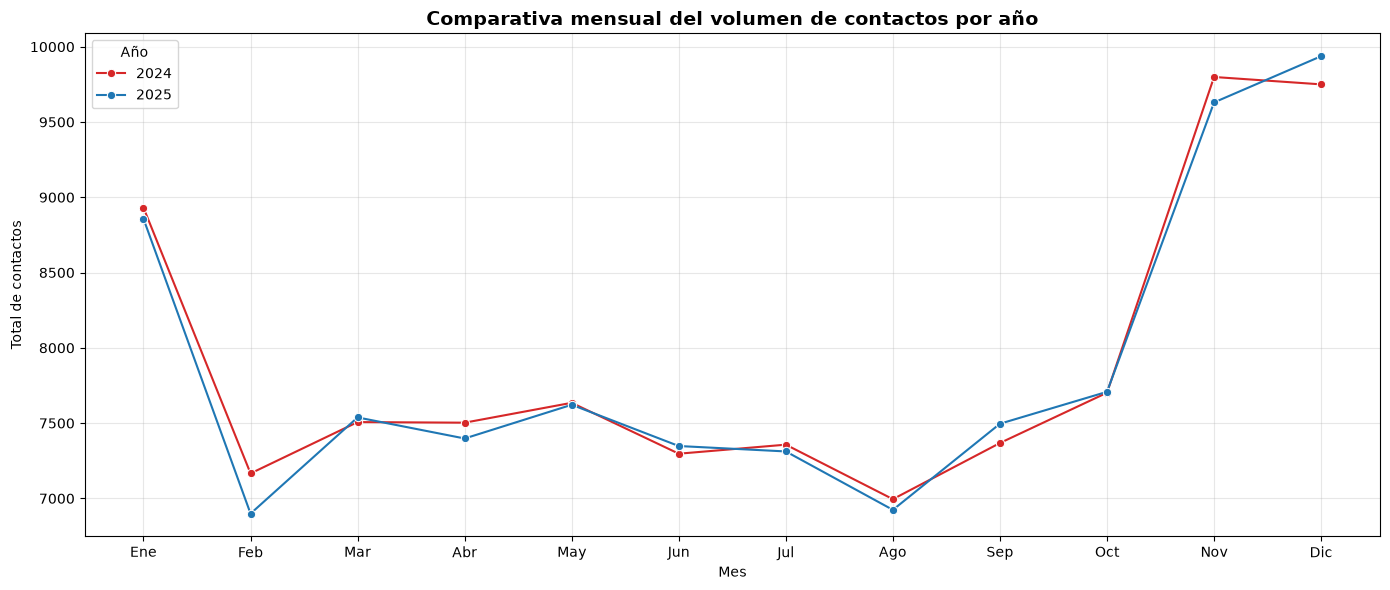

In [14]:
contactos_mes_anio = df_contactos.groupby(['anio', 'mes']).size().reset_index(name='total_contactos')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=contactos_mes_anio,
    x='mes',
    y='total_contactos',
    hue='anio',
    marker='o',
    palette=['#d62728', '#1f77b4']  # opcional, un color por año
)
plt.title('Comparativa mensual del volumen de contactos por año', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Total de contactos')
plt.xticks(ticks=range(1, 13), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(title='Año')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Total volumen por área 2024 vs. 2025

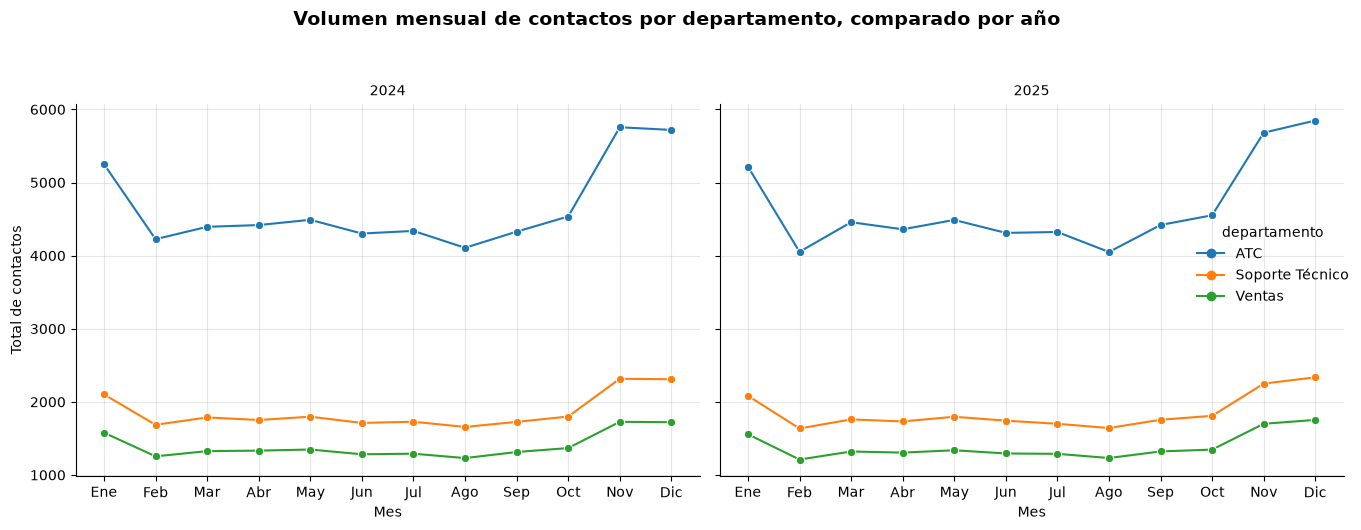

In [15]:
contactos_mes_anio_depto = df_contactos.groupby(['anio', 'mes', 'departamento']).size().reset_index(name='total_contactos')

g = sns.relplot(
    data=contactos_mes_anio_depto,
    x='mes',
    y='total_contactos',
    hue='departamento',
    col='anio',
    kind='line',
    marker='o',
    height=5,
    aspect=1.2
)

g.set_axis_labels('Mes', 'Total de contactos')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
    ax.grid(True, alpha=0.3)

g.fig.suptitle('Volumen mensual de contactos por departamento, comparado por año', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Total volumen por área y campaña 2024 vs. 2025

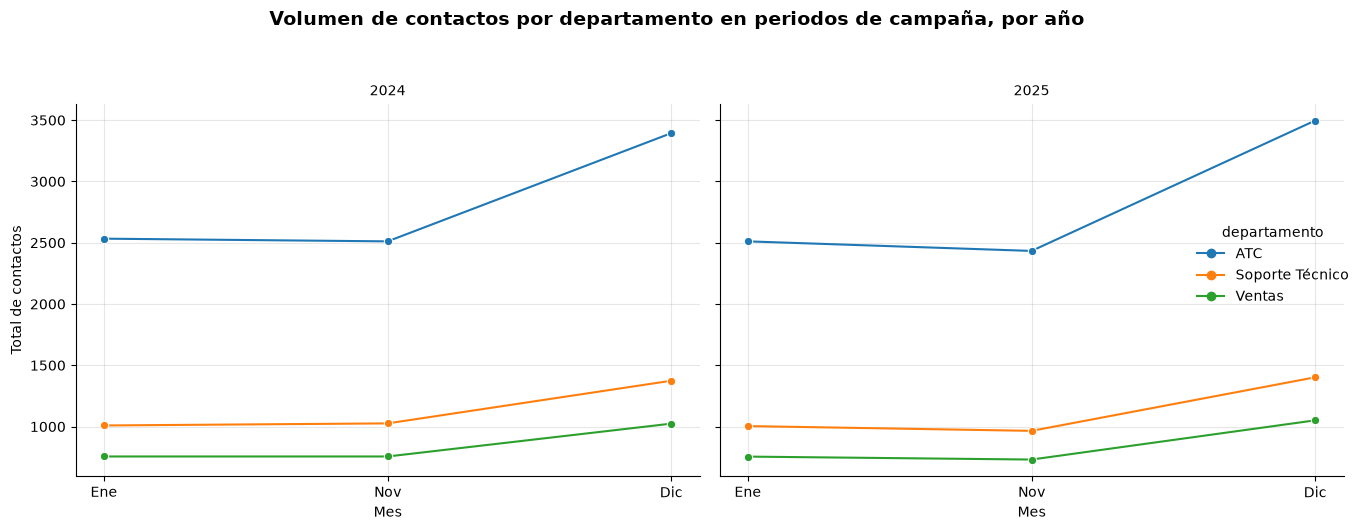

In [16]:
mes_por_campaña = df_campañas.set_index('campania')['mes_num'].to_dict()

meses_ordenados = sorted(df_campañas['mes_num'].unique())
nombres_mes = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
orden_meses = [nombres_mes[m] for m in meses_ordenados]

contactos_campaña = df_contactos[df_contactos['campania'] != 'No']

# Volumen por año, mes y departamento, solo en periodos de campaña
volumen_campania_depto = (
    contactos_campaña
    .groupby(['anio', 'mes', 'departamento'])
    .size()
    .reset_index(name='total_contactos')
)

# Orden de los meses de campaña, calculado dinámicamente desde df_campanias
nombres_mes = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

meses_ordenados = sorted(df_campañas['mes_num'].unique())
orden_meses = [nombres_mes[m] for m in meses_ordenados]

# Columna de mes como texto, para poder mapear nombres
volumen_campania_depto['mes_nombre'] = volumen_campania_depto['mes'].map(nombres_mes)

# Convertir a categórica con el orden correcto (evita huecos en el eje X)
volumen_campania_depto['mes_nombre'] = pd.Categorical(
    volumen_campania_depto['mes_nombre'],
    categories=orden_meses,
    ordered=True
)

# Gráfica
g = sns.relplot(
    data=volumen_campania_depto,
    x='mes_nombre',
    y='total_contactos',
    hue='departamento',
    col='anio',
    kind='line',
    marker='o',
    height=5,
    aspect=1.2
)

g.set_axis_labels('Mes', 'Total de contactos')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)

g.fig.suptitle('Volumen de contactos por departamento en periodos de campaña, por año', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


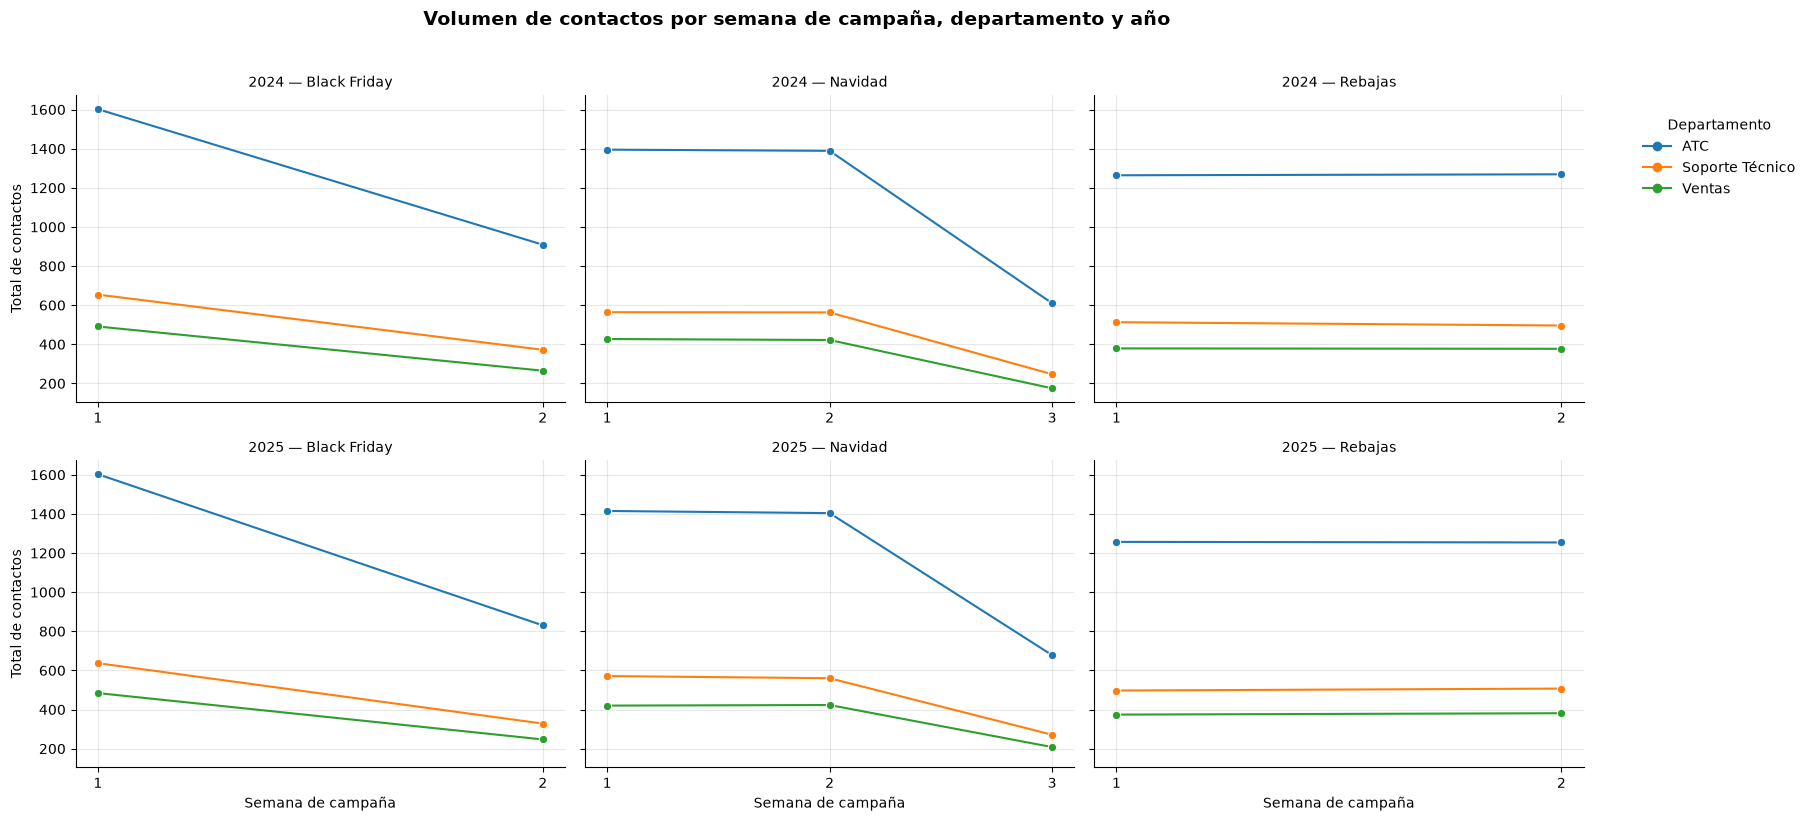

In [20]:
contactos_campania = df_contactos[df_contactos['campania'] != 'No'].copy()
contactos_campania['campania'] = contactos_campania['campania'].cat.remove_unused_categories()

# Para cada fila, calcular a qué día de la campaña corresponde
contactos_campania['dia_campania'] = (
    contactos_campania.groupby(['campania', 'anio'])['fecha']
    .transform(lambda x: (x - x.min()).dt.days)
)

# Y agrupar esos días en semanas relativas a la campaña (semana 1, 2, 3...)
contactos_campania['semana_campania'] = (contactos_campania['dia_campania'] // 7) + 1

volumen_campania_semana = (
    contactos_campania
    .groupby(['campania', 'anio', 'semana_campania', 'departamento'])
    .size()
    .reset_index(name='total_contactos')
)

g = sns.relplot(
    data=volumen_campania_semana,
    x='semana_campania',
    y='total_contactos',
    hue='departamento',
    col='campania',
    row='anio',
    kind='line',
    marker='o',
    height=4,
    aspect=1.2,
    facet_kws={'sharex': False}
)

g.set_axis_labels('Semana de campaña', 'Total de contactos')
g.set_titles('{row_name} — {col_name}')
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # fuerza números enteros en el eje

sns.move_legend(g, loc='upper left', bbox_to_anchor=(1.02, 0.9), title='Departamento')

g.fig.suptitle('Volumen de contactos por semana de campaña, departamento y año', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()